# Experiment 4: Heldout confirmation

In this experiment earlier results are confirmed using the heldout dataset, that was never looked at during tuning. Nothing is varied. Model, prompt, and reps are all frozen, taking the results of experiments 1 to 3. The only thing that changes here is the data.

### What this can and cannot confirm

| can confirm | cannot confirm |
|---|---|
| consistency stays comparable | accuracy as the heldout set has the same sub-MMU problem |
| calibration stays comparable | whether the model is right, an expert is necessary here |
| parse/validity rates hold | |
| cost per row holds | |

Experiment 4 is there to confirm that we did not overfit. To test accuracy and validity an expert is needed.

In [ ]:
import sys
import os
import pandas as pd

sys.path.insert(0, os.path.abspath('../..'))

from testing.util.analysis import cells_of, load_reference, guard, calibration, cost_of
from testing.util.process import process_csv
from testing.util.config import RESULT_PATH, WORKING_DATA100, HELDOUT_DATA100
from testing.util.plots import plot_working_vs_heldout_confidence, plot_confidence_by_difficulty, plot_calibration_comparison

from testing.util.gee_mapping import get_clc_mapping

# ---- FROZEN. Filled using winners from exp2 and exp3 ----
MODEL   = 'gpt-5.4-mini'    # exp 3 winner (prospective)
VERSION = 5                 # exp 2 winner
REPS    = 5               

heldout = pd.read_csv(HELDOUT_DATA100, dtype={'row_id': str})
working = pd.read_csv(WORKING_DATA100, dtype={'row_id': str})

get_clc_mapping(HELDOUT_DATA100, f'{RESULT_PATH}/corine_output_heldout.csv')
get_clc_mapping(WORKING_DATA100, f'{RESULT_PATH}/corine_output_working.csv')

REFH = load_reference(f'{RESULT_PATH}/corine_output_heldout.csv')
REFW = load_reference(f'{RESULT_PATH}/corine_output_working.csv')
print(f'FROZEN: model={MODEL} version=v{VERSION} reps={REPS} | {len(working)} testing rows')
print(f'FROZEN: model={MODEL} version=v{VERSION} reps={REPS} | {len(heldout)} heldout rows')

FROZEN: model=gpt-5.4-mini version=v5 reps=5 | 102 testing rows
FROZEN: model=gpt-5.4-mini version=v5 reps=5 | 98 heldout rows


In [ ]:
async def run(df, reps):
    frames = []
    for rep in range(reps):
        r = await process_csv(df, MODEL, VERSION)
        r['row_id'], r['difficulty'] = df['row_id'].values, df['difficulty_tag'].values
        r['rep'], r['version'] = rep, VERSION
        frames.append(r)
    return pd.concat(frames, ignore_index=True)

OUTH = f'{RESULT_PATH}/exp4_heldout.csv'
raw_h = await run(heldout, REPS)
raw_h.to_csv(OUTH, index=False)
guard(raw_h, expect_variant=f'v{VERSION}', expect_model=MODEL, label='heldout')
print('wrote', OUTH, raw_h.shape)

wrote /home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/results/exp4_heldout.csv (490, 32)


In [8]:
OUTW = f'{RESULT_PATH}/exp4_working.csv'
raw_w = await run(working, REPS)
raw_w.to_csv(OUTW, index=False)
guard(raw_w, expect_variant=f'v{VERSION}', expect_model=MODEL, label='working')
print('wrote', OUTW, raw_w.shape)

2026-07-12 18:39:16,865 INFO Retrying request to /chat/completions in 0.426991 seconds


wrote /home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/results/exp4_working.csv (510, 32)


### Working vs heldout 
A meaningful gap on the generalisable metrics (consistency, calibration, validity) means
the config was overfit to the working dataset.

In [ ]:
cw, ch = cells_of(raw_w, REFW), cells_of(raw_h, REFH)

def summarise(cells, raw, label):
    return {
        'set': label,
        'n_rows': len(cells),
        'consistency': cells['consistency'].mean(),
        'mean_conf': cells['mean_conf'].mean(),
        'parse_fail': cells['parse_fail'].mean(),
        'unknown_code': cells['unknown_code'].mean(),
        'rows_lost': int(cells['modal_code'].isna().sum()),
        'agree_L1': cells['agree_L1'].mean(),      # reported; NOT a validation
        'cost_per_row': cost_of(raw['clc_prompt_tokens'].sum(),
                                raw['clc_completion_tokens'].sum(),
                                raw['clc_cached_tokens'].sum(), MODEL) / cells.shape[0] / REPS,
    }

display(pd.DataFrame([summarise(cw, raw_w, 'working'),
                      summarise(ch, raw_h, 'heldout')]).round(4))

,set,n_rows,consistency,mean_conf,parse_fail,unknown_code,rows_lost,agree_L1,cost_per_row
0,working,102,0.8588,0.6587,0.0,0.0,0,0.3838,0.0013
1,heldout,98,0.8367,0.7205,0.0,0.0,0,0.4694,0.0013


We can see that the metrics mostly stayed the same. The `mean_conf` in `working` being slightly lower, might be linked to the 'difficulty' of `working` being higher than that of `heldout`. As the latter agrees more often with the official mapping, the rows might be more obvious than those of `working`.

In [81]:
print(raw_w['difficulty'].value_counts()/5)
print(raw_h['difficulty'].value_counts()/5)

difficulty
thin                     41.0
unambiguous_candidate    40.0
boundary_candidate       18.0
edge_cultivated           3.0
Name: count, dtype: float64
difficulty
thin                     41.0
unambiguous_candidate    40.0
boundary_candidate       17.0
Name: count, dtype: float64


### Shape Comparison

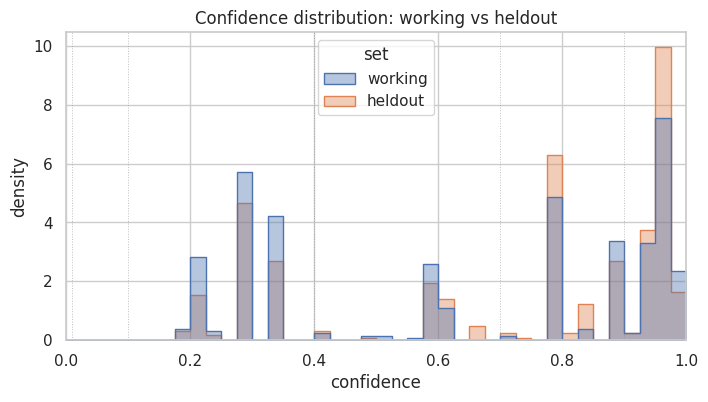

In [61]:
w_vs_h = plot_working_vs_heldout_confidence(raw_w, raw_h)

/home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/util/plots.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  exactly: [0.00, 0.01-0.09, 0.10-0.39, 0.40-0.69, 0.70-0.89, 0.90-1.00]. Confidence
/home/username/uni/sose26/SoPr/project/SWP-SS2026-Classifier-and-Outlier-Detection/testing/util/plots.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  exactly: [0.00, 0.01-0.09, 0.10-0.39, 0.40-0.69, 0.70-0.89, 0.90-1.00]. Confidence


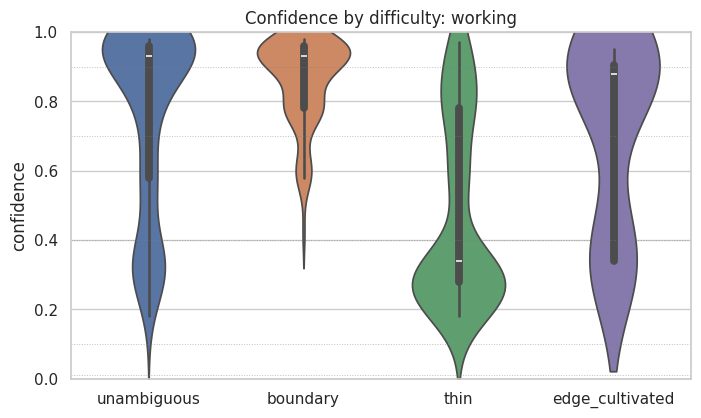

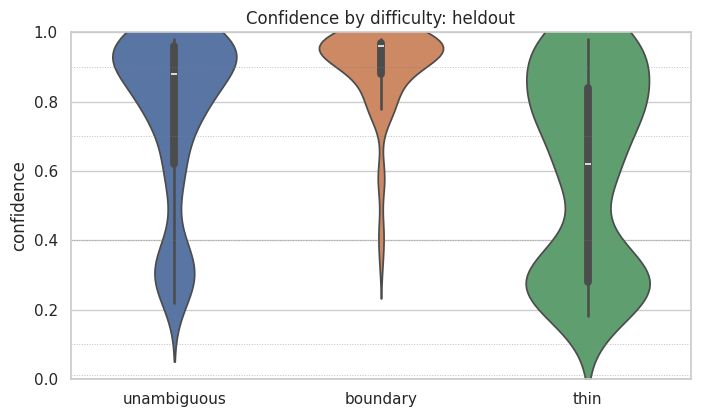

In [65]:
conf_diff_w = plot_confidence_by_difficulty(raw_w, 'Confidence by difficulty: working')
conf_diff_h = plot_confidence_by_difficulty(raw_h, 'Confidence by difficulty: heldout')

In [72]:
print('CALIBRATION (working):')
print(calibration(cw))
print()
print('CALIBRATION (heldout):')
print(calibration(ch))

combined = pd.concat([cw, ch])
print()
print('CALIBRATION (combined):')
print(calibration(combined))

CALIBRATION (working):
               mean  count
band                      
low            0.25      8
mid             0.4      5
high       0.166667      6
very high   0.47619     21

CALIBRATION (heldout):
            mean  count
band                   
low        0.857      7
mid        0.667      3
high       0.667     12
very high  0.333     18

CALIBRATION (combined):
               mean  count
band                      
low        0.533333     15
mid             0.5      8
high            0.5     18
very high  0.410256     39


The individual bands show a trend that could suggest heldout not being well calibrated. Looking at the combined results, however, the curve is flat, which implies that the difference is mostly noise.

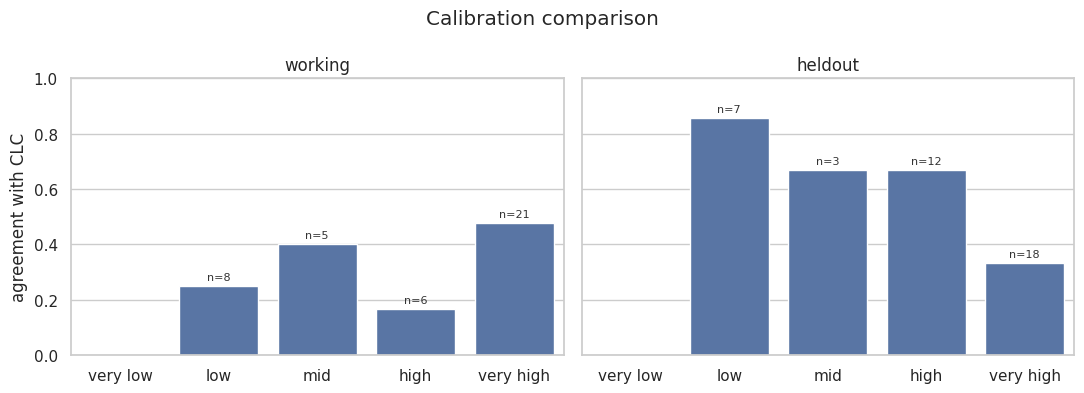

In [69]:
cal_w, cal_h = calibration(cw), calibration(ch)
if not cal_w.empty and not cal_h.empty:
    plot_calibration_comparison(cal_w, cal_h)

## Conclusion

| metric | working | heldout | gap | comparable? |
|---|---|---|---|---|
| consistency | 0.8588 | 0.8367 | 0.0221 | very similar |
| calibration (rises?) | no | no | yes | not really |
| validity (parse/unknown code/rows lost) | 0 | 0 | / | yes |
| cost per row | 0.0013 | 0.0013 | / | yes |
| time | 8m39s | 8m21.9s | 17.1s | very similar |
| agree_L1 | 0.3838 | 0.4694 | 0.0856 | *not a validation* |

**Verdict:** The tuning does not lead to overfitting, however an expert needs to review the results to check for real accuracy. \
**Cost:** At 100k rows with 1 rep each, the current model selection would require ~130 USD. Switching to next best choice (`gpt-4.1-nano`) would reduce the cost to nearly a tenth. \
**Time:** Roughly a second per row.

---

### Left Unanswered

This experiment confirms that the configuration didn't overfit. It does not show that the classifier is right, as CLC cannot establish that (exp 2 and 3 demonstrated why). \
To track accuracy a expert-labelled set would be necessary.